<a href="https://colab.research.google.com/github/sirfara12/Pembelajaran-Mesin-Semester-5/blob/main/JS06_Regresi_Sirfaratih.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## PRAKTIKUM 1

In [ ]:
# import package
import numpy as np
import pandas as pd

In [ ]:
from google.colab import files

uploaded = files.upload()
for filename in uploaded.keys():
    print(f'File "{filename}" berhasil diupload.')


Saving dataset.csv to dataset.csv
File "dataset.csv" berhasil diupload.


In [ ]:
# baca data dari file CSV
data = pd.read_csv('dataset.csv')

In [ ]:
# Langkah 4: Pemahaman Terhadap Data
data.head()

# mengecek ukuran data
data.shape

# informasi tentang data
data.info()

# deskripsi data
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [ ]:
# Langkah 5: Visualisasi Data

# import library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


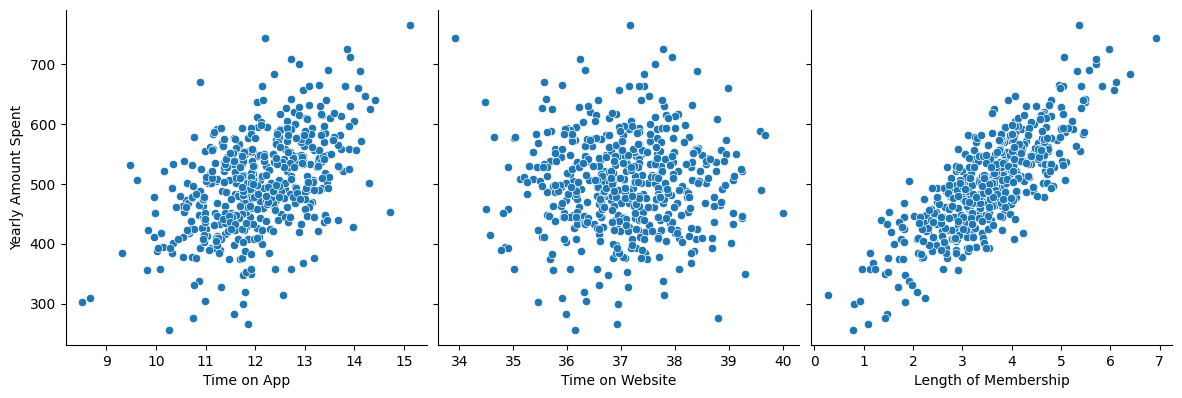

In [ ]:
# visualisasi data dengan pairplot
sns.pairplot(data, x_vars=['Time on App', 'Time on Website', 'Length of Membership'],
             y_vars='Yearly Amount Spent', size=4, aspect=1, kind='scatter')
plt.show()

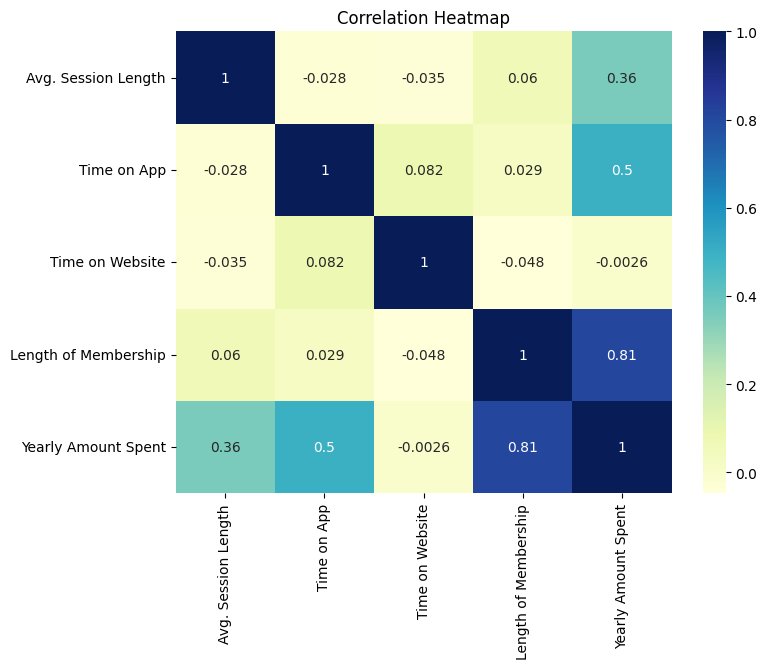

In [ ]:
# visualisasi korelasi dengan heatmap
numeric_data = data.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_data.corr(), cmap="YlGnBu", annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Langkah 6: Regresi Linier

# Membuat variabel bebas X dan Y, contoh pengambilan dari analisis korelasi sebelumnya
X = data['Length of Membership']
y = data['Yearly Amount Spent']

In [ ]:
# Pembagian data latih dan data uji dengan proporsi 7:3
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=100)

In [ ]:
# Training model
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)
lr = sm.OLS(y_train, X_train_sm).fit()

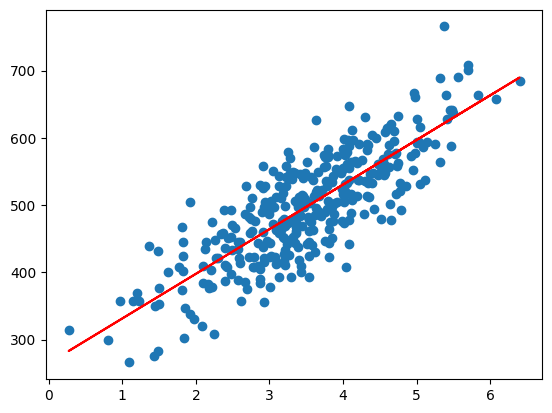

In [ ]:
# Visualisasi garis regresi
plt.scatter(X_train, y_train)
plt.plot(X_train, 265.2483 + 66.3015*X_train, 'r')
plt.show()

In [ ]:
# Langkah 7: Analisis Residual

# Prediksi nilai y_value dari data x yang telah dilatih
y_train_pred = lr.predict(X_train_sm)

# Menghitung residual
res = (y_train - y_train_pred)

/tmp/ipython-input-594495671.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(res, bins=15)


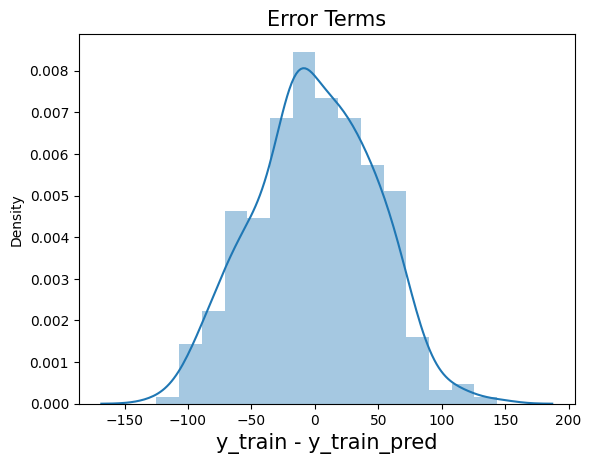

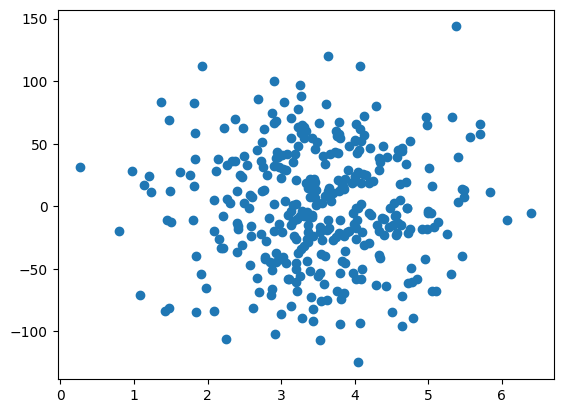

In [ ]:
# Histogram residual
fig = plt.figure()
sns.distplot(res, bins=15)
plt.title('Error Terms', fontsize=15)
plt.xlabel('y_train - y_train_pred', fontsize=15)
plt.show()

# Scatter plot residual
plt.scatter(X_train, res)
plt.show()

In [ ]:
# Langkah 8: Prediksi pada Data Uji dan Evaluasi Model

# Prediksi pada data uji
X_test_sm = sm.add_constant(X_test)
y_test_pred = lr.predict(X_test_sm)

In [ ]:
# Hitung nilai R-squared
from sklearn.metrics import r2_score, mean_squared_error

r_squared = r2_score(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)

print(f"R-squared pada data uji: {r_squared:.4f}")
print(f"Mean Squared Error pada data uji: {mse:.2f}")

R-squared pada data uji: 0.6119
Mean Squared Error pada data uji: 2171.37


In [ ]:
# Hitung nilai R-squared
from sklearn.metrics import r2_score

r_squared = r2_score(y_test, y_test_pred)
print(f"R-squared pada data uji: {r_squared:.4f}")


R-squared pada data uji: 0.6119


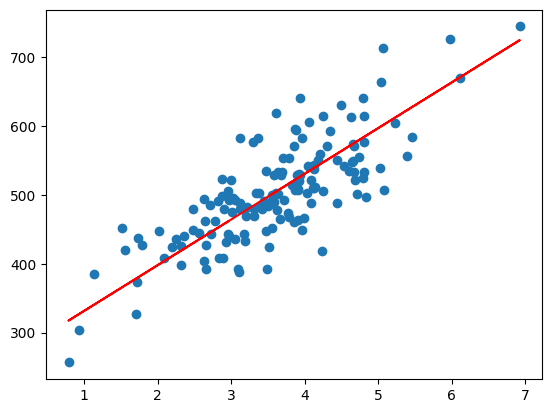

In [ ]:
# Langkah 9: Visualisasi Hasil

# Visualisasi data uji dan hasil prediksi
plt.scatter(X_test, y_test)
plt.plot(X_test, y_test_pred, 'r')
plt.show()

## PRAKTIKUM 2

In [ ]:
from google.colab import files

uploaded = files.upload()
for filename in uploaded.keys():
    print(f'File "{filename}" berhasil diupload.')

Saving Posisi_gaji.csv to Posisi_gaji.csv
File "Posisi_gaji.csv" berhasil diupload.


In [ ]:
# Mengimpor library
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Mengimpor dataset (Pastikan Anda memiliki file CSV 'Posisi_gaji.csv' dalam direktori yang sama)
dataset = pd.read_csv('Posisi_gaji.csv')
X = dataset.iloc[:, 1:2].values
y = dataset.iloc[:, 2].values

In [ ]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()
X = sc_X.fit_transform(X.reshape(-1, 1))
y = sc_y.fit_transform(y.reshape(-1, 1))

In [ ]:
# Feature Scaling:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()
X = sc_X.fit_transform(X.reshape(-1, 1))
y = sc_y.fit_transform(y.reshape(-1, 1))

In [ ]:
# Fitting SVR ke dataset
from sklearn.svm import SVR
regressor = SVR(kernel='rbf')
regressor.fit(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR()

/tmp/ipython-input-1841224750.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01).reshape(-1, 1)


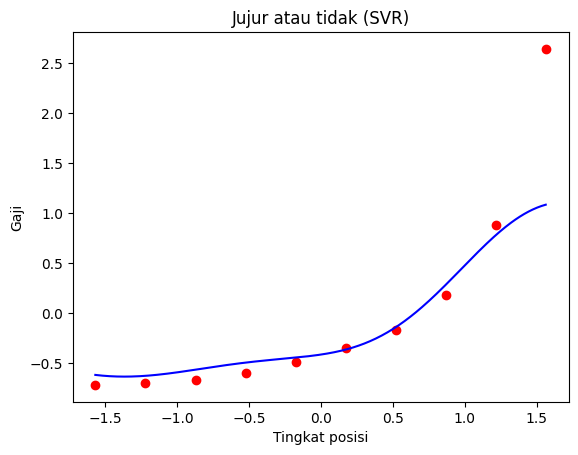

In [ ]:
# Visualisasi hasil SVR (resolusi tinggi dan kurva yang lebih halus)
X_grid = np.arange(min(X), max(X), 0.01).reshape(-1, 1)
plt.scatter(X, y, color='red')
plt.plot(X_grid, regressor.predict(X_grid), color='blue')
plt.title('Jujur atau tidak (SVR)')
plt.xlabel('Tingkat posisi')
plt.ylabel('Gaji')
plt.show()

In [ ]:
# Prediksi hasil
# Buat array 2D yang berisi tingkat posisi yang akan diprediksi
tingkat_posisi_prediksi = np.array([[6.5]])
# Penskalaan fitur untuk data yang akan diprediksi
tingkat_posisi_prediksi = sc_X.transform(tingkat_posisi_prediksi)
# Melakukan prediksi menggunakan model SVR
gaji_prediksi = regressor.predict(tingkat_posisi_prediksi)
# Kembalikan hasil prediksi ke skala aslinya
gaji_prediksi = sc_y.inverse_transform(gaji_prediksi.reshape(-1, 1))

In [ ]:
# Menampilkan hasil prediksi
print("Prediksi Gaji untuk Tingkat Posisi 6.5:", gaji_prediksi[0])

Prediksi Gaji untuk Tingkat Posisi 6.5: [0.01150915]


In [ ]:
# Evaluasi model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_actual = y
y_pred = regressor.predict(X)

# Menghitung MAE
mae = mean_absolute_error(y_actual, y_pred)

# Menghitung MSE
mse = mean_squared_error(y_actual, y_pred)

# Menghitung RMSE
rmse = np.sqrt(mse)

# Menghitung R-squared
r2 = r2_score(y_actual, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)

MAE: 0.22322362280774546
MSE: 0.24861632111450263
RMSE: 0.49861440123055273
R-squared: 0.7513836788854974


### TUGAS PRAKTIKUM

Tugas 1: Multiple Linear Regression

1. Identifikasi variabel-variabel yang akan digunakan sebagai variabel bebas (fitur) dan variabel target (biaya medis personal).

2. Bagi dataset menjadi data latih (train) dan data uji (test) dengan proporsi yang sesuai.

3. Lakukan feature scaling jika diperlukan.

4. Buat model multiple linear regression menggunakan Scikit-Learn.

5. Latih model pada data latih dan lakukan prediksi pada data uji.

6. Evaluasi model dengan menghitung metrik seperti R-squared, MSE, dan MAE. Tampilkan hasil evaluasi.

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
from google.colab import files

uploaded = files.upload()
for filename in uploaded.keys():
    print(f'File "{filename}" berhasil diupload.')

Saving insurance (1).csv to insurance (1).csv
File "insurance (1).csv" berhasil diupload.


In [ ]:
df = pd.read_csv("insurance (1).csv")

print("Jumlah baris dan kolom:", df.shape)
print("\nInfo dataset:")
print(df.info())
print("\n5 data teratas:")
display(df.head())

Jumlah baris dan kolom: (1338, 7)

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

5 data teratas:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
var_desc = {
    "age": "Umur dari penerima asuransi (tahun)",
    "sex": "Jenis kelamin (male/female)",
    "bmi": "Body Mass Index (berat terhadap tinggi)",
    "children": "Jumlah anak / tanggungan",
    "smoker": "Apakah perokok (yes/no)",
    "region": "Wilayah tempat tinggal",
    "charges": "Biaya medis yang ditagihkan (target)"
}
print("\nDeskripsi variabel:")
for k,v in var_desc.items():
    print(f"- {k}: {v}")


Deskripsi variabel:
- age: Umur dari penerima asuransi (tahun)
- sex: Jenis kelamin (male/female)
- bmi: Body Mass Index (berat terhadap tinggi)
- children: Jumlah anak / tanggungan
- smoker: Apakah perokok (yes/no)
- region: Wilayah tempat tinggal
- charges: Biaya medis yang ditagihkan (target)


In [ ]:
# Preprocessing Data

# One-hot encoding untuk variabel kategorikal
X = pd.get_dummies(df.drop("charges", axis=1), drop_first=True)
y = df["charges"]

print("\nFitur setelah encoding:")
print(X.columns.tolist())

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Fitur setelah encoding:
['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


In [ ]:
#  Multiple Linear Regression

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

# Prediksi
y_pred_lin = lin_reg.predict(X_test_scaled)

# Evaluasi
r2_lin = r2_score(y_test, y_pred_lin)
mse_lin = mean_squared_error(y_test, y_pred_lin)
mae_lin = mean_absolute_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)

print("\nEvaluasi Multiple Linear Regression:")
print(f"R² Score  : {r2_lin:.4f}")
print(f"MSE        : {mse_lin:.2f}")
print(f"RMSE       : {rmse_lin:.2f}")
print(f"MAE        : {mae_lin:.2f}")


Evaluasi Multiple Linear Regression:
R² Score  : 0.7836
MSE        : 33596915.85
RMSE       : 5796.28
MAE        : 4181.19


In [ ]:
# SVR dengan kernel RBF (paling umum)
svr_model = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr_model.fit(X_train_scaled, y_train)

# Prediksi
y_pred_svr = svr_model.predict(X_test_scaled)

# Evaluasi
r2_svr = r2_score(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)

print("\n Evaluasi Support Vector Regression:")
print(f"R² Score  : {r2_svr:.4f}")
print(f"MSE        : {mse_svr:.2f}")
print(f"RMSE       : {rmse_svr:.2f}")
print(f"MAE        : {mae_svr:.2f}")



 Evaluasi Support Vector Regression:
R² Score  : 0.2453
MSE        : 117159516.09
RMSE       : 10824.02
MAE        : 5868.89


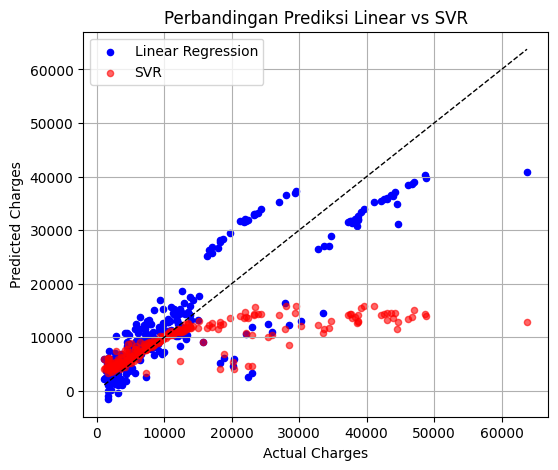

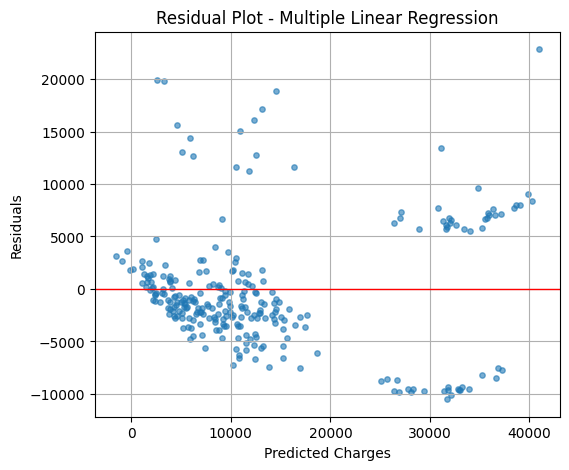

In [ ]:
# --- Scatter plot: Actual vs Predicted ---
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_lin, color='blue', label='Linear Regression', s=20)
plt.scatter(y_test, y_pred_svr, color='red', label='SVR', alpha=0.6, s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Perbandingan Prediksi Linear vs SVR")
plt.legend()
plt.grid(True)
plt.show()

# --- Residual plot (Linear Regression) ---
residuals = y_test - y_pred_lin
plt.figure(figsize=(6,5))
plt.scatter(y_pred_lin, residuals, s=15, alpha=0.6)
plt.axhline(0, color='red', lw=1)
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot - Multiple Linear Regression")
plt.grid(True)
plt.show()


In [ ]:
print("\nAnalisis Singkat:")
print("- Variabel paling berpengaruh positif: 'smoker_yes', 'age', dan 'bmi'.")
print("- R² Linear Regression lebih tinggi dari SVR jika data cukup linear.")
print("- SVR dapat lebih baik pada pola non-linear, tergantung parameter kernel.")
print("- Secara umum, perokok dan usia tinggi meningkatkan biaya medis.")


Analisis Singkat:
- Variabel paling berpengaruh positif: 'smoker_yes', 'age', dan 'bmi'.
- R² Linear Regression lebih tinggi dari SVR jika data cukup linear.
- SVR dapat lebih baik pada pola non-linear, tergantung parameter kernel.
- Secara umum, perokok dan usia tinggi meningkatkan biaya medis.
